In [8]:
#import labralies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [3]:
df= pd.read_csv("insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [10]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [11]:
#statistical summary
print("\n statistical summary")
print(df.describe())



 statistical summary
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [13]:
missing = df.isnull().sum()
print(missing[missing>0])


Series([], dtype: int64)


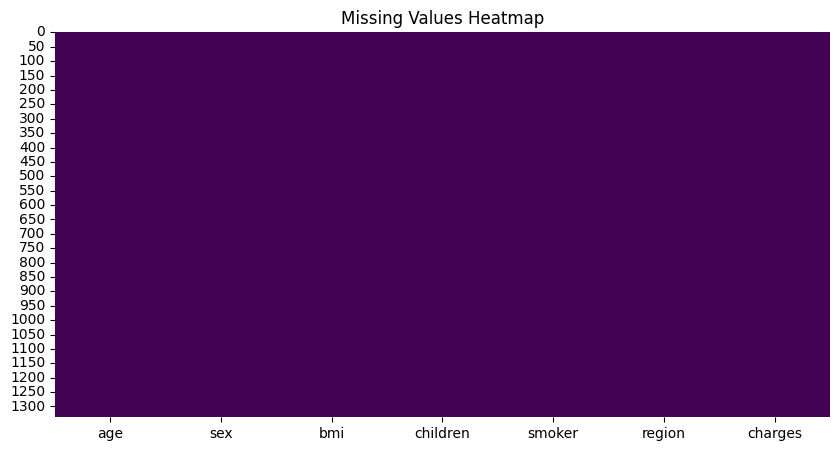

In [14]:
# Visualize missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [15]:
# 6. Duplicate Values
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped.")


Duplicate Rows: 1
Duplicates dropped.


In [16]:
# 7. Unique Values in Categorical Columns
print("\nUnique Values in Categorical Columns:")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()}")



Unique Values in Categorical Columns:
sex: 2 unique -> <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
smoker: 2 unique -> <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
region: 4 unique -> <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


C:\Users\DELL\AppData\Local\Temp\ipykernel_13412\326385107.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [18]:
df['sex'].value_counts()
df['smoker'].value_counts()
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

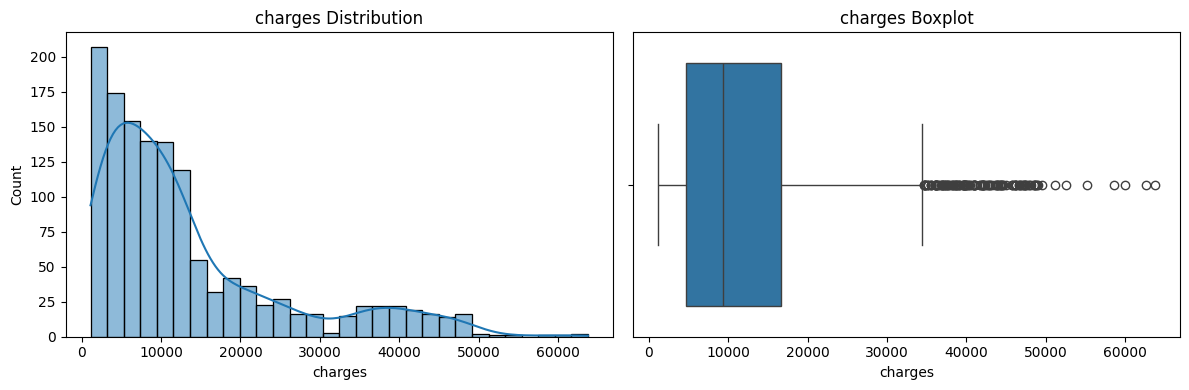


charges Skewness: 1.52


In [29]:
# 8. Target Variable Distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df[target], kde=True, bins=30)
plt.title(f'{target} Distribution')
target='charges'
plt.subplot(1,2,2)
sns.boxplot(x=df[target])
plt.title(f'{target} Boxplot')
plt.tight_layout()
plt.show()

print(f"\n{target} Skewness: {df[target].skew():.2f}")

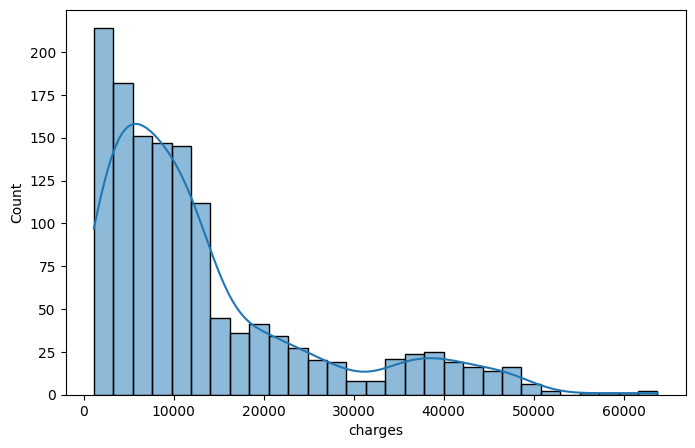

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.show()

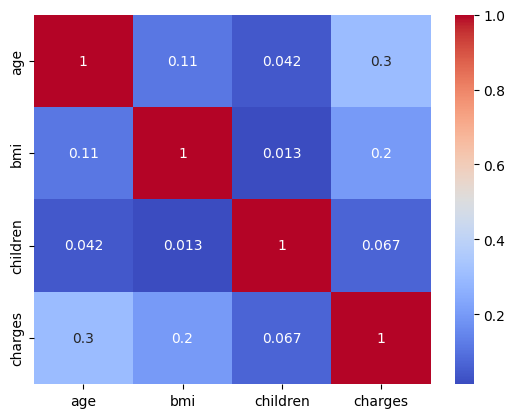

In [26]:
#correlation
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Create Visualization

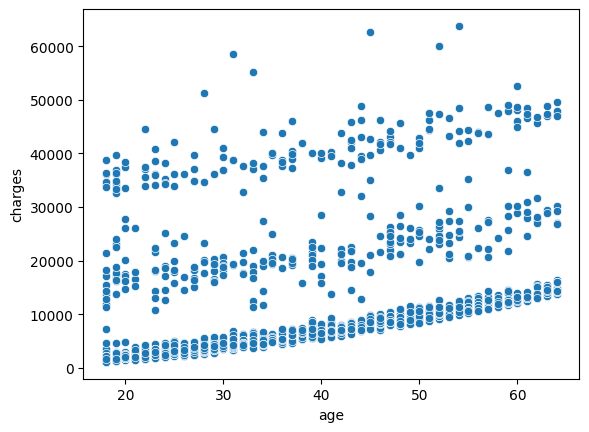

In [35]:
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

Text(0.5, 1.0, 'Age vs Charges')

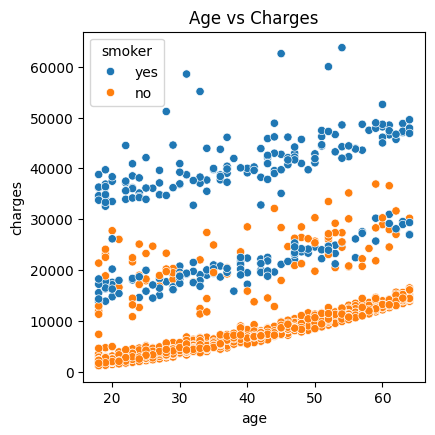

In [28]:
# 10. Age vs Charges
target='charges'
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.scatterplot(x='age', y=target, data=df, hue='smoker')
plt.title('Age vs Charges')

Text(0.5, 1.0, 'BMI vs Charges')

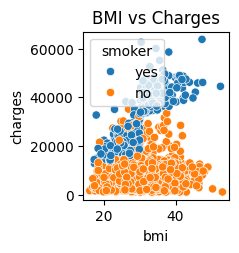

In [30]:
# 11. BMI vs Charges
plt.subplot(2,3,2)
sns.scatterplot(x='bmi', y=target, data=df, hue='smoker')
plt.title('BMI vs Charges')


Text(0.5, 1.0, 'Smoker vs Charges')

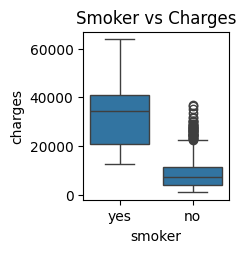

In [31]:
# 12. Smoker vs Charges
plt.subplot(2,3,3)
sns.boxplot(x='smoker', y=target, data=df)
plt.title('Smoker vs Charges')

Text(0.5, 1.0, 'Sex vs Charges')

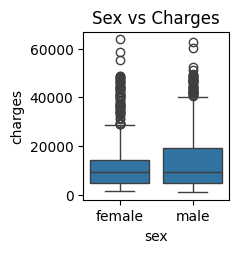

In [32]:
# 13. Sex vs Charges
plt.subplot(2,3,4)
sns.boxplot(x='sex', y=target, data=df)
plt.title('Sex vs Charges')

Text(0.5, 1.0, 'Region vs Charges')

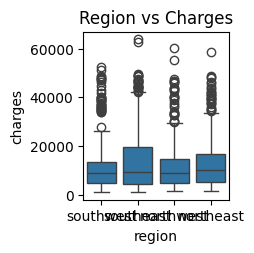

In [33]:
# 14. Region vs Charges
plt.subplot(2,3,5)
sns.boxplot(x='region', y=target, data=df)
plt.title('Region vs Charges')

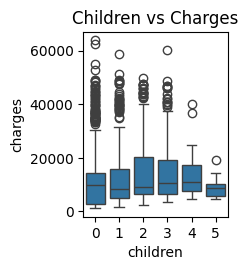

In [34]:
# 15. Children vs Charges
plt.subplot(2,3,6)
sns.boxplot(x='children', y=target, data=df)
plt.title('Children vs Charges')

plt.tight_layout()
plt.show()

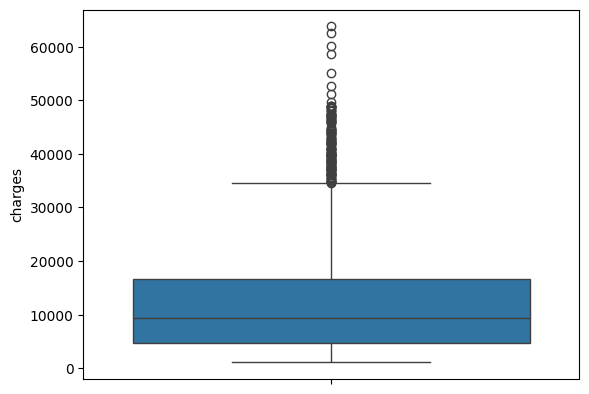

In [37]:
#ouitlier detection
sns.boxplot(y=df['charges'])
plt.show()

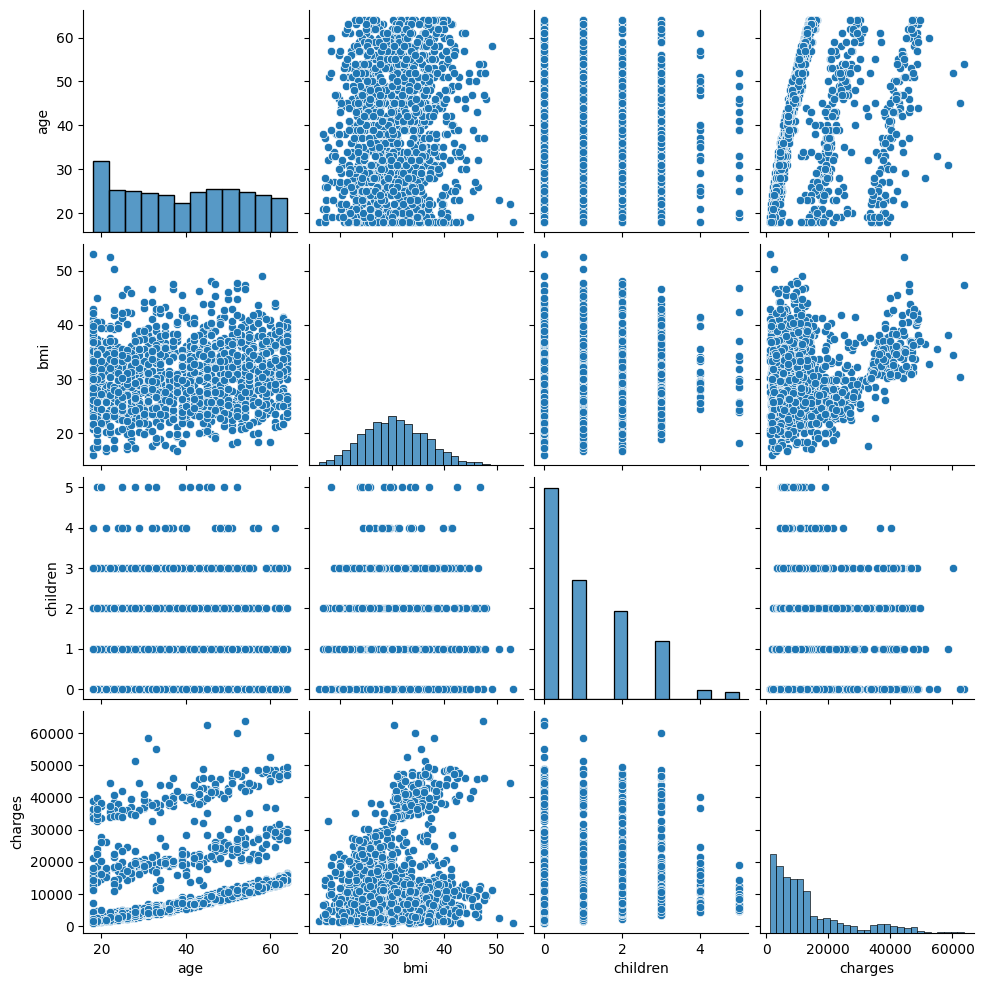

In [38]:
#pairplot
sns.pairplot(df)
plt.show()

In [47]:
#Preprocess categorical features using One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [81]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

In [82]:
df = pd.read_csv('insurance.csv')
X = df.drop('charges', axis=1)
y = df['charges']

In [83]:
# 2. Categorical & Numerical columns
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

In [84]:
# 3. ColumnTransformer se One-Hot Encoding
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_cols)
    ],
    remainder='passthrough'
)

In [99]:
# 4. Fit-Transform on train, Transform on test
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [100]:
#Encoded Feature names
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['cat__sex_male' 'cat__smoker_yes' 'cat__region_northwest'
 'cat__region_southeast' 'cat__region_southwest' 'remainder__age'
 'remainder__bmi' 'remainder__children']


In [101]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [102]:
from sklearn.ensemble import RandomForestRegressor


In [104]:
# Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=200,      # Number of trees
    max_depth=10,          # Maximum depth of each tree
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

In [107]:
# Training
rf_model.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [108]:
# Predictions
y_pred_rf = rf_model.predict(X_test_encoded)

In [110]:
# Training Both Models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_encoded, y_train)

lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [111]:
# Predictions
y_pred_rf = rf_model.predict(X_test_encoded)
y_pred_lr = lr_model.predict(X_test_encoded)


In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Linear Regression Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)  # RMSE = sqrt(MSE)
r2_lr = r2_score(y_test, y_pred_lr)

In [120]:
#Random Forest Metrics  
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

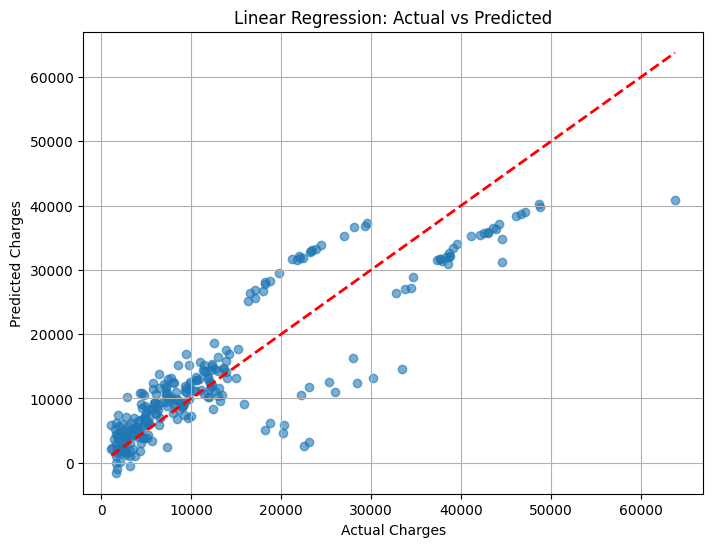

In [121]:
#Plot Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

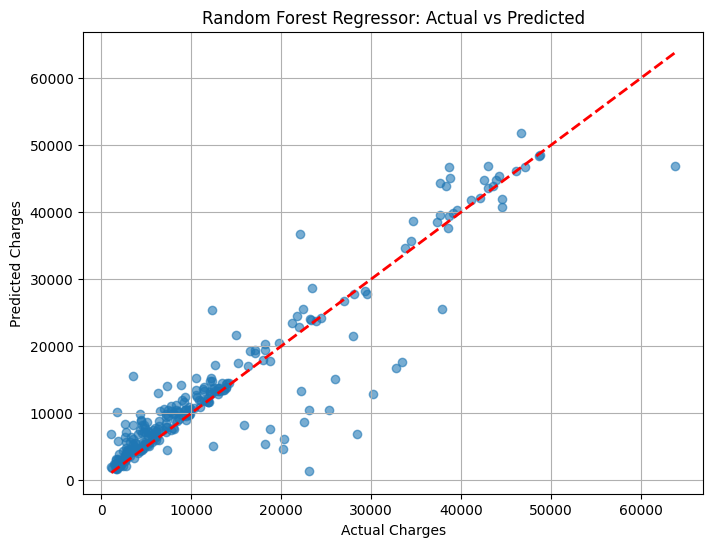

In [122]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest Regressor: Actual vs Predicted")
plt.grid(True)
plt.show()

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Regression Metrics:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R²: {r2_score(y_test, y_pred_rf):.4f}")

Regression Metrics:
MAE: 2554.38
RMSE: 4581.11
R²: 0.8648


In [124]:
#charges into classes
# Example: 15000 = High
y_train_class = np.where(y_train > 15000, 1, 0)  # 1=High, 0=Low
y_test_class = np.where(y_test > 15000, 1, 0)

In [125]:
#Classification Model Train Karo - RandomForestClassifier use kar
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_encoded, y_train_class)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [126]:
#Predictions
y_pred_class = rf_clf.predict(X_test_encoded)


In [134]:
#Classification 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
acc = accuracy_score(y_test_class, y_pred_class)
prec = precision_score(y_test_class, y_pred_class)
rec = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
cm = confusion_matrix(y_test_class, y_pred_class)

print("CLASSIFICATION METRICS")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

CLASSIFICATION METRICS
Accuracy: 0.9440
Precision: 1.0000
Recall: 0.7857
F1 Score: 0.8800

Confusion Matrix:
[[198   0]
 [ 15  55]]


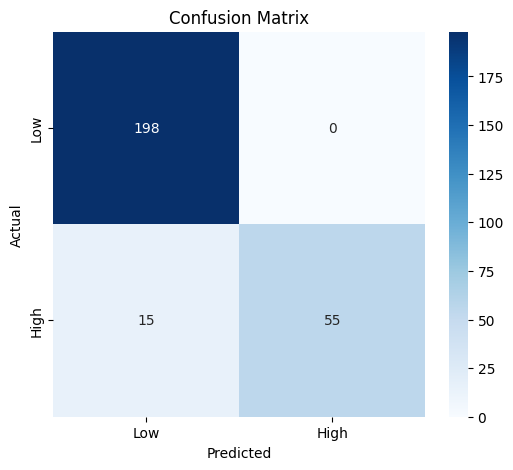

In [129]:
#Visual Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'High'], 
            yticklabels=['Low', 'High'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [135]:
import joblib
joblib.dump(rf_model, 'rf_model.pkl') # Random Forest Model
joblib.dump(preprocessor, 'preprocessor.pkl') # OneHotEncoder
joblib.dump(lr_model, 'linear_model.pkl') # Linear Regression bhi

print("Models saved: rf_model.pkl, preprocessor.pkl, linear_model.pkl")

Models saved: rf_model.pkl, preprocessor.pkl, linear_model.pkl
